In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("Titanic-Dataset.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Shape:", data.shape)
data.isnull().sum()

Shape: (891, 12)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = data[features]
y = data["Survived"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [6]:
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.799


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[97 13]
 [23 46]]


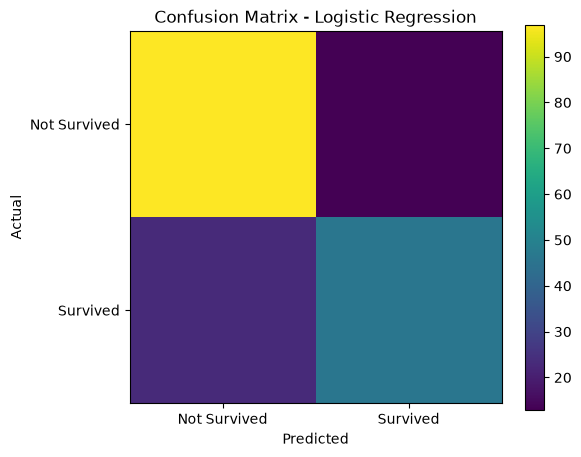

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])

plt.colorbar()
plt.show()

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



In [11]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.3f}")

Decision Tree Accuracy: 0.810


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_accuracy:.3f}")

KNN Accuracy: 0.676


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        knn_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.798883
1,Decision Tree,0.810056
2,KNN,0.675978


In [16]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10]

results = []

for depth in depths:
    dt = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    dt.fit(X_train, y_train)

    y_pred_depth = dt.predict(X_test)

    acc = accuracy_score(y_test, y_pred_depth)

    results.append({
        "max_depth": depth,
        "accuracy": acc
    })

depth_results = pd.DataFrame(results)

depth_results

,max_depth,accuracy
0,1,0.776536
1,2,0.759777
2,3,0.793296
3,4,0.798883
4,5,0.793296
5,6,0.804469
6,7,0.798883
7,8,0.804469
8,10,0.798883


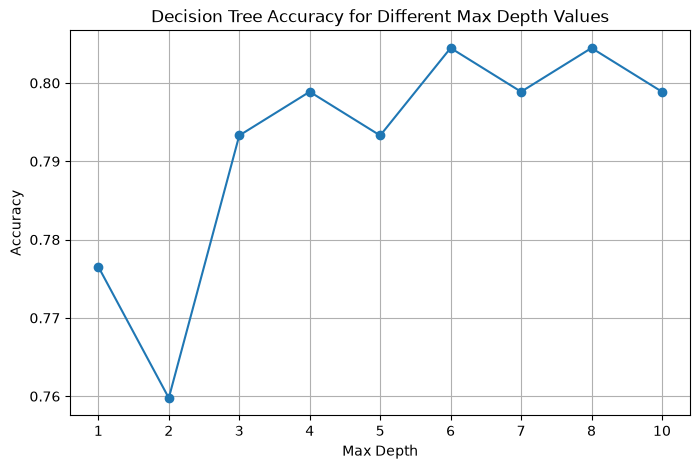

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results["max_depth"].astype(str),
    depth_results["accuracy"],
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy for Different Max Depth Values")
plt.grid(True)

plt.show()

In [18]:
best_result = depth_results.loc[
    depth_results["accuracy"].idxmax()
]

print("Best max_depth:", best_result["max_depth"])
print(f"Accuracy: {best_result['accuracy']:.3f}")

Best max_depth: 6.0
Accuracy: 0.804


## Conclusion

The Week 2 practice exercises were completed using the Titanic dataset.

A Logistic Regression model achieved an accuracy of 0.799, while the default
Decision Tree achieved an accuracy of 0.810. The K-Nearest Neighbors (KNN)
model achieved an accuracy of 0.676 on the same test data.

Different `max_depth` values were tested for the Decision Tree. Among the
tested values, `max_depth = 6` achieved an accuracy of 0.804.

The experiment demonstrates that different classification algorithms can
produce different results on the same dataset, and that hyperparameters such
as `max_depth` can affect Decision Tree performance.